In [7]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
#from webdriver_manager.chrome import ChromeDriverManager
 
driver = webdriver.Chrome(
    service=Service(executable_path=r"E:\NIVEAU4\Stage\Projet1\drivers\chromedriver.exe")
)
driver.get('https://www.google.com')
print('✅ Selenium OK — Titre de la page :', driver.title)
driver.quit()


✅ Selenium OK — Titre de la page : Google


In [8]:
import easyocr
# La première exécution télécharge les modèles (~500 Mo) — normal
reader = easyocr.Reader(['fr', 'en'])
print('✅ EasyOCR prêt — langues chargées : français + anglais')


✅ EasyOCR prêt — langues chargées : français + anglais


In [ ]:
print("--- Vérification de l'environnement Stage YB-TECHs S1 ---")
 
import selenium
print('✅ Selenium :', selenium.__version__)
 
import cv2
print('✅ OpenCV :', cv2.__version__)
 
import pandas
print('✅ Pandas :', pandas.__version__)
 
import fastapi
print('✅ FastAPI :', fastapi.__version__)
 
import chromadb
print('✅ ChromaDB :', chromadb.__version__)
 
import easyocr
print('✅ EasyOCR importé')
 
import requests
try:
    r = requests.get('http://localhost:11434/api/tags', timeout=3)
    models = [m['name'] for m in r.json()['models']]
    print('✅ Ollama actif — Modèles :', models)
except:
    print('❌ Ollama non actif — Lance : ollama serve')
 
print('--- Vérification terminée ---')


--- Vérification de l'environnement Stage YB-TECHs S1 ---
✅ Selenium : 4.18.1
✅ OpenCV : 4.6.0
✅ Pandas : 2.1.4
✅ FastAPI : 0.110.0
✅ ChromaDB : 0.5.0
✅ EasyOCR importé
✅ Ollama actif — Modèles : ['phi3:mini']
--- Vérification terminée ---


In [10]:
# Test de la fonction create_driver et close_driver
import sys
sys.path.insert(0, r'E:\NIVEAU4\Stage\Projet1')
 
from src.selenium_layer.navigator import create_driver, close_driver
 
# Test : ouvre Google
driver = create_driver(headless=False)  # headless=False = tu vois la fenêtre
driver.get('https://www.google.com')
print('✅ Page chargée :', driver.title)
close_driver(driver)


INFO:src.selenium_layer.navigator:Driver Chrome créé — headless=False, timeout=30s


✅ Page chargée : Google


INFO:src.selenium_layer.navigator:Driver Chrome fermé.


In [12]:
# Test de la fonction wait_for_element, waiter pour attendre le chargement d'un élément
from src.selenium_layer.navigator import create_driver, close_driver
from src.selenium_layer.waiter import wait_for_element
from src.selenium_layer.extractor import extract_links, extract_text_by_selector
from bs4 import BeautifulSoup
import pandas as pd
 
driver = create_driver(headless=False)
driver.get('https://books.toscrape.com')
#driver.get('https://google.com')
 
# Attendre que la page soit chargée
wait_for_element(driver, 'article.product_pod')
 
# Extraire les livres
soup = BeautifulSoup(driver.page_source, 'lxml')
livres = []
for article in soup.select('article.product_pod'):
    titre = article.select_one('h3 a')['title']
    prix  = article.select_one('p.price_color').get_text(strip=True)
    note  = article.select_one('p.star-rating')['class'][1]
    livres.append({'titre': titre, 'prix': prix, 'note': note})
 
df = pd.DataFrame(livres)
print(f'✅ {len(df)} livres extraits')
print(df.head())
 
close_driver(driver)


INFO:src.selenium_layer.navigator:Driver Chrome créé — headless=False, timeout=30s
INFO:src.selenium_layer.waiter:Élément trouvé : article.product_pod


✅ 20 livres extraits
                                   titre    prix   note
0                   A Light in the Attic  £51.77  Three
1                     Tipping the Velvet  £53.74    One
2                             Soumission  £50.10    One
3                          Sharp Objects  £47.82   Four
4  Sapiens: A Brief History of Humankind  £54.23   Five


INFO:src.selenium_layer.navigator:Driver Chrome fermé.


In [13]:
#Test de la fonction scrape_all_pages, pagination automatique
from src.selenium_layer.navigator import create_driver, close_driver
from src.selenium_layer.waiter import wait_for_element
from src.selenium_layer.paginator import scrape_all_pages
from bs4 import BeautifulSoup
import pandas as pd
 
def extraire_livres_page(driver):
    '"""Extrait les livres de la page courante."""'
    soup = BeautifulSoup(driver.page_source, 'lxml')
    livres = []
    for article in soup.select('article.product_pod'):
        livres.append({
            'titre': article.select_one('h3 a')['title'],
            'prix': article.select_one('p.price_color').get_text(strip=True),
            'note': article.select_one('p.star-rating')['class'][1]
        })
    return livres
 
driver = create_driver(headless=True)  # headless=True = plus rapide
driver.get('https://books.toscrape.com')
wait_for_element(driver, 'article.product_pod')
 
# Scrape les 3 premières pages
tous_les_livres = scrape_all_pages(
    driver,
    extract_func=extraire_livres_page,
    next_selector='li.next a',
    max_pages=3
)
 
df = pd.DataFrame(tous_les_livres)
print(f'✅ {len(df)} livres extraits sur 3 pages')
print(df.head(10))
 
# Sauvegarde
df.to_csv('data/processed/livres_scrapes.csv', index=False)
print('✅ Sauvegardé dans data/processed/livres_scrapes.csv')
close_driver(driver)


INFO:src.selenium_layer.navigator:Driver Chrome créé — headless=True, timeout=30s
INFO:src.selenium_layer.waiter:Élément trouvé : article.product_pod
INFO:src.selenium_layer.paginator:Extraction page 1...
INFO:src.selenium_layer.paginator:  → 20 éléments extraits sur cette page.
INFO:src.selenium_layer.paginator:Page suivante chargée.
INFO:src.selenium_layer.paginator:Extraction page 2...
INFO:src.selenium_layer.paginator:  → 20 éléments extraits sur cette page.
INFO:src.selenium_layer.paginator:Page suivante chargée.
INFO:src.selenium_layer.paginator:Extraction page 3...
INFO:src.selenium_layer.paginator:  → 20 éléments extraits sur cette page.
INFO:src.selenium_layer.paginator:Page suivante chargée.
INFO:src.selenium_layer.paginator:Pagination terminée : 4 page(s), 60 éléments au total.


✅ 60 livres extraits sur 3 pages
                                               titre    prix   note
0                               A Light in the Attic  £51.77  Three
1                                 Tipping the Velvet  £53.74    One
2                                         Soumission  £50.10    One
3                                      Sharp Objects  £47.82   Four
4              Sapiens: A Brief History of Humankind  £54.23   Five
5                                    The Requiem Red  £22.65    One
6  The Dirty Little Secrets of Getting Your Dream...  £33.34   Four
7  The Coming Woman: A Novel Based on the Life of...  £17.93  Three
8  The Boys in the Boat: Nine Americans and Their...  £22.60   Four
9                                    The Black Maria  £52.15    One
✅ Sauvegardé dans data/processed/livres_scrapes.csv


INFO:src.selenium_layer.navigator:Driver Chrome fermé.


In [14]:
# Test de l'extraction d'un tableau de population mondiale depuis Worldometers
from src.selenium_layer.navigator import create_driver, close_driver
from src.selenium_layer.waiter import wait_for_element
from src.selenium_layer.extractor import extract_table
import pandas as pd
import json
from datetime import datetime
 
# ── CONFIGURATION ─────────────────────────────────────────────
URL = 'https://www.worldometers.info/world-population/population-by-country/'
 
# ── EXTRACTION ────────────────────────────────────────────────
driver = create_driver(headless=True)
driver.get(URL)
 
# Attendre le tableau
wait_for_element(driver, 'table#example2')
 
# Extraire le tableau
df = extract_table(driver, table_index=0)
close_driver(driver)
 
# ── NETTOYAGE ─────────────────────────────────────────────────
if df is not None:
    # Supprimer les lignes vides
    df.dropna(how='all', inplace=True)
    df.reset_index(drop=True, inplace=True)
    
    print(f'✅ {len(df)} pays extraits')
    print(df.head())
    
    # ── SAUVEGARDE CSV ─────────────────────────────────────────
    csv_path = 'data/processed/population_mondiale.csv'
    df.to_csv(csv_path, index=False, encoding='utf-8-sig')
    print(f'✅ CSV sauvegardé : {csv_path}')
    
    # ── SAUVEGARDE JSON ────────────────────────────────────────
    json_path = 'data/processed/population_mondiale.json'
    rapport = {
        'timestamp': datetime.now().isoformat(),
        'source': URL,
        'nb_enregistrements': len(df),
        'colonnes': list(df.columns),
        'donnees': df.to_dict(orient='records')
    }
    with open(json_path, 'w', encoding='utf-8') as f:
        json.dump(rapport, f, ensure_ascii=False, indent=2)
    print(f'✅ JSON sauvegardé : {json_path}')


INFO:src.selenium_layer.navigator:Driver Chrome créé — headless=True, timeout=30s
INFO:src.selenium_layer.extractor:Tableau extrait : 234 lignes, 12 colonnes
INFO:src.selenium_layer.navigator:Driver Chrome fermé.


✅ 234 pays extraits
   # Country (or dependency) Population 2026 Yearly Change  Net Change  \
0  1                   India   1,476,625,576         0.87%  12,760,051   
1  2                   China   1,412,914,089        −0.22%  −3,182,005   
2  3           United States     349,035,494         0.51%   1,759,687   
3  4               Indonesia     287,886,782         0.76%   2,165,546   
4  5                Pakistan     259,299,791          1.6%   4,080,237   

  Density (P/Km²) Land Area (Km²) Migrants (net) Fert. Rate Median Age  \
0             497       2,973,190       −440,456       1.93       29.2   
1             150       9,388,211       −232,107       1.03       40.6   
2              38       9,147,420      1,177,848       1.63       38.7   
3             159       1,811,570        −39,472       2.08       30.7   
4             336         770,880     −1,144,738       3.44       20.8   

  Urban Pop % World Share  
0       37.6%       17.8%  
1       68.7%         17%  
2     

In [15]:
from src.selenium_layer.navigator import create_driver, close_driver
from src.selenium_layer.waiter import wait_for_element
from bs4 import BeautifulSoup
import re, json, time

# ── L'utilisateur entre juste une URL et une question ──────────
URL      = input("🌐 URL à analyser : ").strip()
QUESTION = input("❓ Que cherches-tu ? (ex: contacts, localisation, services...) : ").strip()

driver = create_driver(headless=True)
driver.get(URL)
wait_for_element(driver, 'body', timeout=15)
soup = BeautifulSoup(driver.page_source, 'lxml')
texte = soup.get_text(separator=' ', strip=True)

print(f'\n✅ Page chargée : {driver.title}')
print(f'📄 {len(texte)} caractères récupérés')

INFO:src.selenium_layer.navigator:Driver Chrome créé — headless=True, timeout=30s
INFO:src.selenium_layer.waiter:Élément trouvé : body



✅ Page chargée : YB-Techs: Solutions digitales innovantes et sur mesure | YB-TECHS
📄 2894 caractères récupérés


In [16]:
# ── Extraction aveugle — on ne sait rien du site à l'avance ────

resultats = {}

# CONTACTS : emails
emails = list(set(re.findall(r'[\w.+\-]+@[\w\-]+\.[a-zA-Z]{2,}', texte)))
if emails:
    resultats['CONTACTS_EMAIL'] = emails

# CONTACTS : téléphones
tels = list(set(re.findall(r'(?:\+?\d{1,3}[\s\-.]?)?\(?\d{2,4}\)?[\s\-.]?\d{2,4}[\s\-.]?\d{2,4}[\s\-.]?\d{0,4}', texte)))
tels = [t.strip() for t in tels if 8 <= len(re.sub(r'\D','',t)) <= 15]
if tels:
    resultats['CONTACTS_TEL'] = tels[:5]

# LOCALISATION : adresses (mots-clés universels)
mots_geo = re.findall(r'\b(?:rue|avenue|boulevard|route|allée|impasse|street|road|city|ville|cedex|bp|po box|\d{4,6})\b.{0,60}', texte.lower())
if mots_geo:
    resultats['LOCALISATION'] = list(set(mots_geo))[:5]

# IDENTITE : titres H1/H2/H3
titres = [h.get_text(strip=True) for h in soup.find_all(['h1','h2','h3']) if h.get_text(strip=True)]
if titres:
    resultats['IDENTITE'] = titres[:8]

# SERVICES / PRODUITS : listes <ul><li> substantielles
items = [li.get_text(strip=True) for li in soup.select('ul li, ol li')
         if 10 < len(li.get_text(strip=True)) < 150]
if items:
    resultats['SERVICES_PRODUITS'] = list(dict.fromkeys(items))[:10]

# RESEAUX SOCIAUX : liens vers plateformes connues
reseaux = {}
plateformes = ['linkedin','facebook','twitter','instagram','github','youtube','tiktok']
for a in soup.find_all('a', href=True):
    for p in plateformes:
        if p in a['href'].lower() and p not in reseaux:
            reseaux[p] = a['href']
if reseaux:
    resultats['RESEAUX_SOCIAUX'] = reseaux

# INFORMATIONS GENERALES : paragraphes informatifs
paragraphes = [p.get_text(strip=True) for p in soup.find_all('p')
               if 40 < len(p.get_text(strip=True)) < 300]
if paragraphes:
    resultats['INFORMATIONS'] = list(dict.fromkeys(paragraphes))[:6]

# LIENS UTILES : liens internes et externes
liens = [{'texte': a.get_text(strip=True), 'href': a['href']}
         for a in soup.find_all('a', href=True)
         if a.get_text(strip=True) and len(a.get_text(strip=True)) > 3]
if liens:
    resultats['LIENS_UTILES'] = liens[:10]

# ── Affichage ───────────────────────────────────────────────────
print(f'\n🔍 Question : "{QUESTION}"')
print(f'🌐 Source   : {URL}')
print('='*55)
for categorie, valeurs in resultats.items():
    print(f'\n📂 {categorie}')
    if isinstance(valeurs, dict):
        for k, v in valeurs.items():
            print(f'   {k} → {v}')
    elif isinstance(valeurs, list):
        for v in valeurs:
            print(f'   • {v}')


🔍 Question : "Les contacts"
🌐 Source   : https://yb-techs.eu/

📂 CONTACTS_EMAIL
   • ybtechs.io@gmail.com

📂 CONTACTS_TEL
   • 6 59 28 72 21
   • 6 76 65 71 62

📂 LOCALISATION
   • 14200 hérouville-saint clair, france opening hours monday to frid
   • 2026.  all rights reserved.

📂 IDENTITE
   • Innovate with YB-TECHs
   • About Us
   • 3
   • 5
   • Our Services
   • Customer Reviews
   • Our Location

📂 SERVICES_PRODUITS
   • About the CEO
   • Data analysis & AI strategy– from planning to implementation
   • Tailored AI solutions– designed to unlock your company’s full potential

📂 RESEAUX_SOCIAUX
   linkedin → /httpswwwlinkedincominyris-brice-wandji-piugie
   facebook → https://www.facebook.com/yrbrtechs
   instagram → https://www.instagram.com/106851293
   tiktok → https://tiktok.com/

📂 INFORMATIONS
   • Turning Data and Technology into Business Growth
   • We collect, structure, and analyze your data to extract actionable insights. Your information thus becomes a real lever for

In [17]:
# ── Réponse ciblée selon la question posée ──────────────────────
mots_question = QUESTION.lower()

cibles = {
    'contact'     : ['CONTACTS_EMAIL', 'CONTACTS_TEL'],
    'email'       : ['CONTACTS_EMAIL'],
    'téléphone'   : ['CONTACTS_TEL'],
    'localisation': ['LOCALISATION'],
    'adresse'     : ['LOCALISATION'],
    'service'     : ['SERVICES_PRODUITS'],
    'produit'     : ['SERVICES_PRODUITS'],
    'info'        : ['IDENTITE', 'INFORMATIONS'],
    'réseau'      : ['RESEAUX_SOCIAUX'],
    'lien'        : ['LIENS_UTILES'],
}

categories_pertinentes = []
for mot, cats in cibles.items():
    if mot in mots_question:
        categories_pertinentes.extend(cats)

print(f'\n💡 RÉPONSE À : "{QUESTION}"')
print('='*55)
if categories_pertinentes:
    for cat in set(categories_pertinentes):
        if cat in resultats:
            print(f'\n✅ {cat}')
            val = resultats[cat]
            if isinstance(val, dict):
                for k, v in val.items():
                    print(f'   {k} → {v}')
            else:
                for v in val:
                    print(f'   • {v}')
        else:
            print(f'\n❌ {cat} → Aucune donnée trouvée sur ce site')
else:
    print('💬 Question trop générale — voici tout ce qui a été trouvé :')
    for cat in resultats:
        print(f'   → {cat} ({len(resultats[cat])} éléments)')

# ── Sauvegarde JSON ─────────────────────────────────────────────
sortie = {
    'question': QUESTION,
    'url'     : URL,
    'titre'   : driver.title,
    'resultats': resultats
}
nom_fichier = f"data/processed/scraping_{URL.split('//')[-1].split('/')[0].replace('.','_')}.json"
with open(nom_fichier, 'w', encoding='utf-8') as f:
    json.dump(sortie, f, ensure_ascii=False, indent=2)

close_driver(driver)
print(f'\n✅ Sauvegardé → {nom_fichier}')


💡 RÉPONSE À : "Les contacts"

✅ CONTACTS_TEL
   • 6 59 28 72 21
   • 6 76 65 71 62

✅ CONTACTS_EMAIL
   • ybtechs.io@gmail.com


INFO:src.selenium_layer.navigator:Driver Chrome fermé.



✅ Sauvegardé → data/processed/scraping_yb-techs_eu.json


In [18]:
import sys
sys.path.insert(0, r'E:\NIVEAU4\Stage\Projet1')
from src.ocr_layer.security import valider_fichier
 
# Test 1 : fichier valide
try:
    valider_fichier('tests/fixtures/ocr/IMG1.png')
    print('✅ Fichier valide')
except Exception as e:
    print(f'❌ {e}')
 
# Test 2 : mauvaise extension
try:
    valider_fichier('tests/fixtures/ocr/fichier.exe')
except ValueError as e:
    print(f'✅ Rejet correct : {e}')


INFO:src.ocr_layer.security:Fichier validé : tests/fixtures/ocr/IMG1.png (75605 octets)


✅ Fichier valide
✅ Rejet correct : Extension non autorisée : .exe. Autorisées : {'.png', '.tiff', '.pdf', '.jpg', '.bmp', '.jpeg'}


INFO:src.ocr_layer.preprocessor:Image améliorée sauvegardée : tests/fixtures/ocr/amelioree.png
INFO:src.ocr_layer.preprocessor:Preprocessing terminé pour : tests/fixtures/ocr/IMG4.png


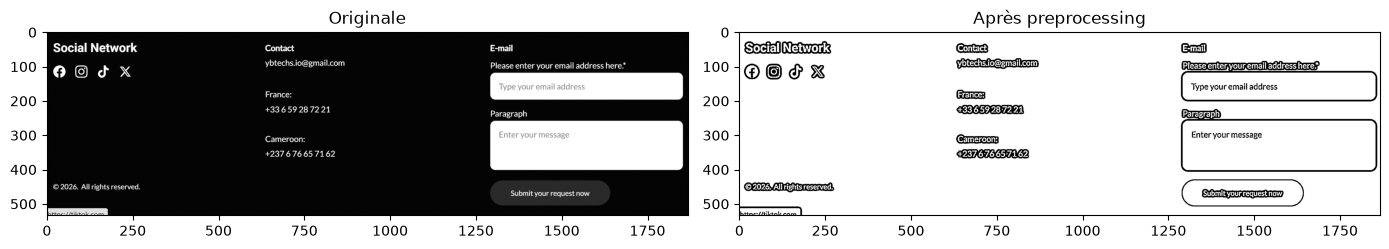

✅ Preprocessing OK — compare les deux images ci-dessus


In [19]:
from src.ocr_layer.preprocessor import ameliorer_image
import cv2
import matplotlib.pyplot as plt
 
# Prend un screenshot de yb-techs.eu comme image test
# (ou n'importe quelle image dans tests/fixtures/ocr/)
chemin = 'tests/fixtures/ocr/IMG4.png'
 
img_originale  = cv2.imread(chemin, cv2.IMREAD_GRAYSCALE)
img_amelioree  = ameliorer_image(chemin, 'tests/fixtures/ocr/amelioree.png')
 
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(img_originale,  cmap='gray'); axes[0].set_title('Originale')
axes[1].imshow(img_amelioree,  cmap='gray'); axes[1].set_title('Après preprocessing')
plt.tight_layout()
plt.show()
print('✅ Preprocessing OK — compare les deux images ci-dessus')


In [20]:
from src.ocr_layer.ocr_engine import lire_image
 
# Test sur le screenshot de yb-techs.eu capturé en S2
resultat = lire_image('tests/fixtures/ocr/IMG4.png')
 
print(f'✅ Moteur utilisé : {resultat["moteur"]}')
print(f'   Confiance     : {resultat["confiance"]}')
print(f'   Nb mots       : {resultat["nb_mots"]}')
print(f'   Aperçu texte  : {resultat["texte"][:300]}...')


INFO:src.ocr_layer.security:Fichier validé : tests/fixtures/ocr/IMG4.png (67303 octets)
INFO:src.ocr_layer.preprocessor:Preprocessing terminé pour : tests/fixtures/ocr/IMG4.png
e:\NIVEAU4\Stage\Projet1\agent_pipe\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
INFO:src.ocr_layer.ocr_engine:EasyOCR : 234 caractères, confiance 0.6


✅ Moteur utilisé : easyocr
   Confiance     : 0.6
   Nb mots       : 21
   Aperçu texte  : Sociallletiork Contact Email {Btechsf@@gmailcom Pleaseenteryguremailaddresshere Type your email address France [TEL] Paragrapb Cameroon3 Enter message [TEL] @202 Alrightsresenved Submityourlequestnow htncsutvtavcam Your...


In [21]:
from src.ocr_layer.pipeline_ocr import pipeline_aveugle
 
# ── Test 1 : yb-techs.eu (Selenium suffisant) ─────────────────
res1 = pipeline_aveugle('https://yb-techs.eu/', 'contacts')
print(f'✅ Source utilisée : {res1["source"]}')
print(f'   Contacts        : {res1["resultats"]["CONTACTS_EMAIL"]}')
print(f'   Localisation    : {res1["resultats"]["LOCALISATION"]}')
print()
 
# ── Test 2 : Facebook (probablement fallback OCR) ──────────────
res2 = pipeline_aveugle('https://www.facebook.com/yrbrtechs', 'informations')
print(f'✅ Source utilisée : {res2["source"]}')
print(f'   Informations    : {res2["resultats"]["INFORMATIONS"][:2]}')
print()
 
# ── Test 3 : LinkedIn (probablement fallback OCR) ──────────────
res3 = pipeline_aveugle('https://fr.linkedin.com/company/ybtechs', 'localisation')
print(f'✅ Source utilisée : {res3["source"]}')
print(f'   Localisation    : {res3["resultats"]["LOCALISATION"]}')


INFO:src.selenium_layer.navigator:Driver Chrome créé — headless=True, timeout=30s
INFO:src.selenium_layer.waiter:Élément trouvé : body
INFO:src.ocr_layer.pipeline_ocr:Texte HTML suffisant (2894 chars) → pipeline Selenium
INFO:src.ocr_layer.pipeline_ocr:Résultats sauvegardés : data/processed/pipeline_yb-techs_eu.json
INFO:src.selenium_layer.navigator:Driver Chrome fermé.


✅ Source utilisée : selenium
   Contacts        : ['ybtechs.io@gmail.com']
   Localisation    : ['14200 hérouville-saint clair, france opening hours monday to frid', '2026.  all rights reserved.']



INFO:src.selenium_layer.navigator:Driver Chrome créé — headless=True, timeout=30s
INFO:src.selenium_layer.waiter:Élément trouvé : body
INFO:src.ocr_layer.pipeline_ocr:Texte HTML suffisant (1103 chars) → pipeline Selenium
INFO:src.ocr_layer.pipeline_ocr:Résultats sauvegardés : data/processed/pipeline_www_facebook_com.json
INFO:src.selenium_layer.navigator:Driver Chrome fermé.


✅ Source utilisée : selenium
   Informations    : [' Mot de passe Se connecter Mot de passe oublié\xa0? ou Créer un nouveau compte']



INFO:src.selenium_layer.navigator:Driver Chrome créé — headless=True, timeout=30s
INFO:src.selenium_layer.waiter:Élément trouvé : body
INFO:src.ocr_layer.pipeline_ocr:Texte HTML suffisant (10374 chars) → pipeline Selenium
INFO:src.ocr_layer.pipeline_ocr:Résultats sauvegardés : data/processed/pipeline_fr_linkedin_com.json
INFO:src.selenium_layer.navigator:Driver Chrome fermé.


✅ Source utilisée : selenium
   Localisation    : ['2025 ', '2020 lieux principal 11, place camille blaisot 14200 hérouville-', 'rue françois 1er 75008 paris, île-de-france, fr obtenir l’itiné', '83390 (near marseille) france 🇫🇷', '2026 à propos accessibilité conditions générales d’utilisation d']


In [22]:
from src.ocr_layer.benchmark import benchmarker
 
# Corpus de 5 images — place tes screenshots dans tests/fixtures/ocr/
corpus = [
    {'nom': 'ybtechs_site',    'chemin': 'tests/fixtures/ocr/IMG1.png',  'texte_reel': ''},
    {'nom': 'facebook_popup',  'chemin': 'tests/fixtures/ocr/IMG2.png', 'texte_reel': ''},
    {'nom': 'linkedin_login',  'chemin': 'tests/fixtures/ocr/IMG3.png', 'texte_reel': ''},
    {'nom': 'image_propre',    'chemin': 'tests/fixtures/ocr/IMG4.png',        'texte_reel': ''},
    {'nom': 'image_bruitee',   'chemin': 'tests/fixtures/ocr/IMG5.png',       'texte_reel': ''},
]
 
df = benchmarker(corpus)
print('✅ Benchmark terminé')
print(df.to_string(index=False))


INFO:src.ocr_layer.preprocessor:Preprocessing terminé pour : tests/fixtures/ocr/IMG1.png
INFO:src.ocr_layer.preprocessor:Preprocessing terminé pour : tests/fixtures/ocr/IMG2.png
INFO:src.ocr_layer.preprocessor:Preprocessing terminé pour : tests/fixtures/ocr/IMG3.png
INFO:src.ocr_layer.preprocessor:Preprocessing terminé pour : tests/fixtures/ocr/IMG4.png
INFO:src.ocr_layer.preprocessor:Preprocessing terminé pour : tests/fixtures/ocr/IMG5.png
INFO:src.ocr_layer.benchmark:Benchmark sauvegardé : data/processed/benchmark_ocr.csv


✅ Benchmark terminé
         Image EasyOCR_CER  EasyOCR_Confiance  EasyOCR_Temps(s) Tesseract_CER  Tesseract_Temps(s) Meilleur
  ybtechs_site        None               0.79             13.18          None                1.88  EasyOCR
facebook_popup        None               0.17             27.80          None                1.17  EasyOCR
linkedin_login        None               0.43             18.96          None                0.37  EasyOCR
  image_propre        None               0.60             10.62          None                0.53  EasyOCR
 image_bruitee        None               0.62             15.93          None                0.90  EasyOCR


# OMNIPARSER

In [23]:
from src.omniparser_layer.omni_engine import analyser_screenshot
 
# Utilise un screenshot capturé en S3 (déjà dans tests/fixtures/ocr/)
elements = analyser_screenshot('tests/fixtures/ocr/IMG5.png')
 
print(f'✅ {len(elements)} éléments UI détectés')
for el in elements[:5]:  # Affiche les 5 premiers
    print(f'   [{el["index"]}] {el["texte"][:60]}')



0: 576x1280 14 icons, 2517.4ms
Speed: 75.3ms preprocess, 2517.4ms inference, 1704.0ms postprocess per image at shape (1, 3, 576, 1280)
len(filtered_boxes): 15 12
time to get parsed content: 40.08951210975647
✅ 15 éléments UI détectés
   [1] {'type': 'text', 'bbox': [0.21604278683662415, 0.37156510353
   [2] {'type': 'text', 'bbox': [0.3534759283065796, 0.720430135726
   [3] {'type': 'icon', 'bbox': [0.02005949057638645, 0.00325617007
   [4] {'type': 'icon', 'bbox': [0.42068687081336975, 0.59891867637
   [5] {'type': 'icon', 'bbox': [0.5964706540107727, 0.107036031782


In [24]:

from src.omniparser_layer.pipeline_omni import pipeline_tri_couche
 
sites = [
    ('https://yb-techs.eu/',                    'contacts'),
    ('https://www.facebook.com/yrbrtechs',      'informations'),
    ('https://fr.linkedin.com/company/ybtechs', 'localisation'),
]
 
for url, question in sites:
    print(f'\n🌐 {url}')
    res = pipeline_tri_couche(url, question)
    print(f'   ✅ Source utilisée : {res["source"]}')
    for cat, val in res['resultats'].items():
        if val:
            print(f'   📂 {cat} : {str(val)[:80]}')



🌐 https://yb-techs.eu/
   ✅ Source utilisée : selenium
   📂 CONTACTS_EMAIL : ['ybtechs.io@gmail.com']
   📂 CONTACTS_TEL : ['+237 6 76 65 71 62', '+33 6 59 28 72 21']
   📂 LOCALISATION : ['14200 hérouville-saint clair, france opening hours monday to frid', '2026.  al
   📂 IDENTITE : ['Innovate with YB-TECHs', 'About Us', '3', '5', 'Our Services', 'Customer Revie
   📂 INFORMATIONS : [' Your information thus becomes a real lever for growth and performance', ' We 
   📂 RESEAUX_SOCIAUX : {'linkedin': '/httpswwwlinkedincominyris-brice-wandji-piugie', 'facebook': 'http

🌐 https://www.facebook.com/yrbrtechs
   ✅ Source utilisée : selenium
   📂 CONTACTS_EMAIL : ['ybtechs.io@gmail.com']
   📂 CONTACTS_TEL : ['106851293', '+33 6 59 28 72 21']
   📂 IDENTITE : ['YB-TECHs', 'Intro', 'Photos', 'YB-TECHs', 'in Science']
   📂 INFORMATIONS : [' Mot de passe Se connecter Mot de passe oublié\xa0? ou Créer un nouveau compte
   📂 RESEAUX_SOCIAUX : {'facebook': 'https://www.facebook.com/recover/initiate?ars=

In [25]:
from src.omniparser_layer.omni_engine import analyser_screenshot
 
# Test avec différents seuils pour calibrer OmniParser
for seuil in [0.03, 0.05, 0.10, 0.15]:
    # Modifie temporairement box_threshold dans omni_engine.py
    elements = analyser_screenshot('tests/fixtures/ocr/IMG1.png')
    print(f'Seuil {seuil} → {len(elements)} éléments détectés')



0: 1184x1280 5 icons, 3634.6ms
Speed: 28.9ms preprocess, 3634.6ms inference, 3.0ms postprocess per image at shape (1, 3, 1184, 1280)
len(filtered_boxes): 45 -1
time to get parsed content: 6.237178564071655
Seuil 0.03 → 45 éléments détectés

0: 1184x1280 5 icons, 3267.9ms
Speed: 26.0ms preprocess, 3267.9ms inference, 3.0ms postprocess per image at shape (1, 3, 1184, 1280)
len(filtered_boxes): 45 -1
time to get parsed content: 6.023287057876587
Seuil 0.05 → 45 éléments détectés

0: 1184x1280 5 icons, 3477.7ms
Speed: 25.5ms preprocess, 3477.7ms inference, 2.0ms postprocess per image at shape (1, 3, 1184, 1280)
len(filtered_boxes): 45 -1
time to get parsed content: 6.515356779098511
Seuil 0.1 → 45 éléments détectés

0: 1184x1280 5 icons, 3587.5ms
Speed: 26.9ms preprocess, 3587.5ms inference, 2.0ms postprocess per image at shape (1, 3, 1184, 1280)
len(filtered_boxes): 45 -1
time to get parsed content: 6.609763860702515
Seuil 0.15 → 45 éléments détectés


In [26]:
from src.orchestrator_layer.llm_classifier import classifier_requete
 
pred = classifier_requete('Extrais les contacts de la page', 'https://yb-techs.eu/')
print(pred)



{'type_interface': 'selenium', 'confiance': 0.95, 'justification': 'La page contient du texte HTML clair et structuré.', 'prompt_extraction': "Utilise Selenium pour naviguer vers la section 'Contacts' sur le site web de YB-Techs."}


In [27]:
from src.orchestrator_layer.pipeline_orchestre import pipeline_oriente
 
urls = [
    ('https://yb-techs.eu/', 'contacts'),
    ('https://yb-techs.eu/', 'services proposés'),
    ('https://yb-techs.eu/', 'réseaux sociaux'),
]
for url, question in urls:
    r = pipeline_oriente(url, question)
    print(f"{question:25s} → prédit={r['prediction_llm']['type_interface']:10s} "
          f"réel={r['source']:10s} concordance={r['concordance']}")



contacts                  → prédit=selenium   réel=ocr        concordance=False


services proposés         → prédit=selenium   réel=ocr        concordance=False
réseaux sociaux           → prédit=selenium   réel=ocr        concordance=False


In [28]:
from src.orchestrator_layer.pipeline_orchestre import pipeline_oriente
from src.cleaning.nettoyeur import nettoyer
from src.storage.stockage import sauvegarder
 
resultat = pipeline_oriente('https://yb-techs.eu/', 'contacts')
df = nettoyer(resultat)
chemins = sauvegarder(df, 'data/processed/ybtechs_scraping')
print(chemins)


{'json': 'data/processed/ybtechs_scraping.json', 'csv': 'data/processed/ybtechs_scraping.csv', 'sqlite': 'data/processed/ybtechs_scraping.db'}


In [29]:
from src.orchestrator_layer.pipeline_orchestre import pipeline_oriente

url = input("🔗 Lien à analyser : ")
question = input("❓ Que veux-tu extraire ? : ")

resultat = pipeline_oriente(url, question)

print("\n" + "="*60)
print(f"🧠 Couche utilisée par le pipeline : {resultat['source']}")
print(f"🎯 Couche prédite par le LLM       : {resultat['prediction_llm']['type_interface']}")
print(f"✅ Prédiction ↔ réalité concordent : {resultat['concordance']}")
print("="*60)

# Champs techniques ajoutés par l'orchestrateur, pas des données extraites
CLES_TECHNIQUES = {'source', 'prediction_llm', 'concordance', 'timestamp_orchestrateur'}

for categorie, contenu in resultat.items():
    if categorie in CLES_TECHNIQUES:
        continue
    print(f"\n📁 {categorie.upper()}")
    print(f"   {contenu}")


🧠 Couche utilisée par le pipeline : ocr
🎯 Couche prédite par le LLM       : selenium
✅ Prédiction ↔ réalité concordent : False

📁 QUESTION
   Je veux des contacts

📁 URL
   https://yb-techs.eu/

📁 TIMESTAMP
   2026-08-01T20:28:16.553089

📁 RESULTATS
   {'CONTACTS_EMAIL': [], 'CONTACTS_TEL': [], 'LOCALISATION': [], 'IDENTITE': [], 'INFORMATIONS': ['YBTechs Accuell Services Expertise Contact About the CEO Transform your data into opportunities with YBTECHS: Data collection & analysis']}

📁 REPONSE_FINALE
   Pour obtenir des contacts et bénéficier de l'expertise en data analysis offerte par YBTECHS, vous pouvez contacter leur service d'allocation pour demander davantage dinformation.

📁 ERREUR_LLM
   False


In [ ]:

########## a partir d'ici et environ 5 autres cellules
from src.orchestrator_layer.pipeline_orchestre import pipeline_oriente

resultat = pipeline_oriente('https://yb-techs.eu/', "contacts de l'entreprise")
print(f"Couche utilisée : {resultat['source']}")
print(f"Réponse : {resultat['reponse_finale']}")
print(f"Panne LLM : {resultat['erreur_llm']}")
print(f"Prédiction a priori vs réel : {resultat['prediction_llm']['type_interface']} "
      f"vs {resultat['source']} → concordance={resultat['concordance']}")


Couche utilisée : ocr
Réponse : Nous pouvons fournir des informations sur les contacts de l'entreprise YB-Techs grâce à notre expertise en analyse structurelle et modélisation algorithmique.
Panne LLM : False
Prédiction a priori vs réel : selenium vs ocr → concordance=False


In [32]:
try:
    resultat = pipeline_oriente('https://yb-techs.eu/', "contacts de l'entreprise")
except Exception as e:
    print(type(e).__name__, ":", str(e))

In [3]:
from src.orchestrator_layer.pipeline_orchestre import pipeline_oriente

url = input("🔗 Lien à analyser : ")
question = input("❓ Que veux-tu extraire ? : ")

resultat = pipeline_oriente(url, question)

print("\n" + "="*60)
print(f"🧠 Couche utilisée         : {resultat['source']}")
print(f"🎯 Prédiction a priori LLM : {resultat['prediction_llm']['type_interface']}")
print(f"✅ Concordance             : {resultat['concordance']}")
print(f"⚠️  Panne LLM (erreur_llm) : {resultat['erreur_llm']}")
print("="*60)

if resultat['erreur_llm']:
    print("\n⚠️  llama n'a pas pu juger/formuler à cet étage — données brutes ci-dessous.")
elif resultat['reponse_finale']:
    print(f"\n💬 Réponse formulée par llama :\n{resultat['reponse_finale']}")
else:
    print("\n⚠️  Pas de réponse formulée (cas inattendu à signaler).")

print("\n📁 Données brutes extraites :")
for categorie, contenu in resultat['resultats'].items():
    print(f"   {categorie}: {contenu}")
    


0: 960x1280 (no detections), 3883.1ms
Speed: 26.5ms preprocess, 3883.1ms inference, 2.0ms postprocess per image at shape (1, 3, 960, 1280)
len(filtered_boxes): 4 -1
time to get parsed content: 10.419829368591309

🧠 Couche utilisée         : selenium
🎯 Prédiction a priori LLM : ocr
✅ Concordance             : False
⚠️  Panne LLM (erreur_llm) : False

💬 Réponse formulée par llama :
Un TEXTE.

📁 Données brutes extraites :
   CONTACTS_EMAIL: []
   CONTACTS_TEL: []
   LOCALISATION: []
   IDENTITE: []
   INFORMATIONS: []
   RESEAUX_SOCIAUX: {}
   IMAGES_DETECTEES: [{'url_image': 'https://i.ytimg.com/vi/jYWvOetcdG0/hqdefault.jpg', 'contenu': {'IDENTITE': ['[COMMENT', 'CONVERTIR', 'Un TEXTE', "EN PAROLE'"]}}]


In [ ]:
from src.selenium_layer.navigator import create_driver, close_driver
from src.selenium_layer.waiter import wait_for_element
from src.ocr_layer.pipeline_ocr import classifier_texte
from src.orchestrator_layer.llm_classifier import juger_resultat_selenium
from bs4 import BeautifulSoup

driver = create_driver(headless=False)
driver.get('https://yb-techs.eu/')
wait_for_element(driver, 'body', timeout=15)
soup = BeautifulSoup(driver.page_source, 'lxml')
texte_html = soup.get_text(separator=' ', strip=True)

resultats = classifier_texte(texte_html)
print("📂 Résultats Selenium AVANT jugement llama :")
for cat, val in resultats.items():
    print(f"  {cat}: {val}")

jugement = juger_resultat_selenium(resultats, "Les contacts", 'https://yb-techs.eu/')
print("\n🧠 Jugement brut renvoyé par llama :", jugement)

close_driver(driver)

📂 Résultats Selenium AVANT jugement Phi-3 :
  CONTACTS_EMAIL: ['ybtechs.io@gmail.com']
  CONTACTS_TEL: ['+237 6 76 65 71 62', '+33 6 59 28 72 21']
  LOCALISATION: ['14200 hérouville-saint clair, france opening hours monday to frid', '2026.  all rights reserved.']
  IDENTITE: []
  INFORMATIONS: [' Your information thus becomes a real lever for growth and performance', ' We design AI models and algorithms tailored to your specific needs to automate, predict, and optimize your processes', ' Our solutions use AI to recognize, identify, and secure', ' From image recognition to biometrics, we develop intelligent systems for greater efficiency and accuracy', ' AI Consulting Digital Consulting & Support About Us At YB-TECHS (Why Be Techs) , we transform data into actionable insights and AI-powered solutions for SMEs across five continents']



🧠 Jugement brut renvoyé par Phi-3 : {'erreur': True}


In [ ]:
import time
import requests

prompt_test = '''Tu analyses des données extraites automatiquement du site https://yb-techs.eu/.

Question de l'utilisateur : Les contacts

Données extraites du DOM de la page (classées par catégorie) :
{"CONTACTS_EMAIL": ["ybtechs.io@gmail.com"], "CONTACTS_TEL": ["+237 6 76 65 71 62", "+33 6 59 28 72 21"], "LOCALISATION": ["14200 hérouville-saint clair, france"]}

Ces données permettent-elles de répondre correctement et complètement à la question ?
Réponds UNIQUEMENT avec un objet JSON valide, sans texte autour :
{"suffisant": true ou false, "reponse": "réponse rédigée en français si suffisant, sinon null"}
'''

debut = time.perf_counter()
r = requests.post('http://localhost:11434/api/generate',
                   json={'model': 'phi3:mini', 'prompt': prompt_test, 'stream': False,
                         'options': {'temperature': 0.1}},
                   timeout=300)  # large exprès, pour mesurer sans couper
print(f"⏱️  Temps de réponse : {time.perf_counter() - debut:.1f} s")
print(r.json()['response'])

In [1]:
import time, requests

debut = time.perf_counter()
r = requests.post('http://localhost:11434/api/generate',
                   json={'model': 'phi3:mini', 'prompt': 'Réponds juste : OK.',
                         'stream': False, 'options': {'num_predict': 10}},
                   timeout=120)
print(f"⏱️ {time.perf_counter() - debut:.1f}s → {r.json()['response']}")

⏱️ 8.9s → OK.


In [2]:
from src.orchestrator_layer.pipeline_orchestre import pipeline_oriente

url = input("🔗 Lien à analyser : ")
question = input("❓ Que veux-tu extraire ? : ")

resultat = pipeline_oriente(url, question)

print("\n" + "="*60)
print(f"🧠 Couche utilisée         : {resultat['source']}")
print(f"🎯 Prédiction a priori LLM : {resultat['prediction_llm']['type_interface']}")
print(f"✅ Concordance             : {resultat['concordance']}")
print(f"⚠️  Panne LLM (erreur_llm) : {resultat['erreur_llm']}")
print("="*60)

if resultat['source'] == 'ocr':
    print(f"\n🔎 Confiance OCR      : {resultat.get('confiance_ocr')}")
    print(f"📝 Texte OCR brut     : {resultat.get('texte_ocr_brut')}")
    print(f"✨ Texte OCR corrigé  : {resultat.get('texte_ocr_corrige')}")

if resultat['erreur_llm']:
    print("\n⚠️  llama n'a pas pu formuler à cet étage.")
elif resultat['reponse_finale']:
    print(f"\n💬 Réponse formulée par llama :\n{resultat['reponse_finale']}")

print("\n📁 Résultats BRUTS de la couche (jamais réécrits par le LLM) :")
for categorie, contenu in resultat['resultats'].items():
    print(f"   {categorie}: {contenu}")

INFO:src.selenium_layer.navigator:Driver Chrome créé — headless=True, timeout=30s
INFO:src.selenium_layer.waiter:Élément trouvé : body
INFO:src.selenium_layer.navigator:Driver Chrome fermé.



0: 960x1280 (no detections), 5715.1ms
Speed: 84.4ms preprocess, 5715.1ms inference, 185.7ms postprocess per image at shape (1, 3, 960, 1280)
len(filtered_boxes): 4 -1
time to get parsed content: 43.51649880409241

🧠 Couche utilisée         : selenium
🎯 Prédiction a priori LLM : selenium
✅ Concordance             : True
⚠️  Panne LLM (erreur_llm) : False

💬 Réponse formulée par llama :
Le texte trouvé est : [COMMENT, 'CONVERTIR', 'Un TEXTE', "EN PAROLE'].

📁 Résultats BRUTS de la couche (jamais réécrits par le LLM) :
   CONTACTS_EMAIL: []
   CONTACTS_TEL: []
   LOCALISATION: []
   IDENTITE: []
   INFORMATIONS: []
   RESEAUX_SOCIAUX: {}
   IMAGES_DETECTEES: [{'url_image': 'https://i.ytimg.com/vi/jYWvOetcdG0/hqdefault.jpg', 'contenu': {'IDENTITE': ['[COMMENT', 'CONVERTIR', 'Un TEXTE', "EN PAROLE'"]}}]


In [1]:
# 1. Import seul — détecte immédiatement une erreur de syntaxe/import
from src.orchestrator_layer.pipeline_orchestre import pipeline_oriente
print("✅ Import OK")

✅ Import OK


In [5]:
# 2. Cas rapide attendu : yb-techs.eu, texte DOM seul doit suffire (pas d'image analysée)
resultat = pipeline_oriente('https://yb-techs.eu/', 'Les contacts')
print(f"Couche: {resultat['source']} | erreur_llm: {resultat['erreur_llm']}")
print(resultat['reponse_finale'])

INFO:src.selenium_layer.navigator:Driver Chrome créé — headless=True, timeout=30s
INFO:src.selenium_layer.waiter:Élément trouvé : body
INFO:src.selenium_layer.navigator:Driver Chrome fermé.


Couche: selenium | erreur_llm: False
Les données fournies indiquent que l’adresse email des contacts est 'ybtechs.io@gmail.com'. Les numéros de téléphone sont disponibles pour deux personnes et incluent les coordonnées internationales françaises, ainsi qu'une autre en France mais avec un lien vers LinkedIn qui semble être incorrectement formatée dans la chaîne JSON fournie (il manque des points avant le 'com'). Les informations sur l’ident
